
=== Seasonal summary ===
# A tibble: 2 × 12
  season    n_micro micro_mean micro_sd pico_mean nano_mean ratio_mean ratio_sd
  <chr>       <int>      <dbl>    <dbl>     <dbl>     <dbl>      <dbl>    <dbl>
1 rainy          42      0.254    0.128     0.439     0.307      0.779    0.842
2 upwelling      41      0.379    0.229     0.375     0.247      2.10     4.13 
# ℹ 4 more variables: chl_mean <dbl>, iso21_mean <dbl>, zoo200_mean <dbl>,
#   zoo500_mean <dbl>

=== HPLC observations per year ===
# A tibble: 23 × 2
    year n_hplc
   <int>  <int>
 1  1995      0
 2  1996      5
 3  1997      3
 4  1998      3
 5  1999      0
 6  2000      3
 7  2001      4
 8  2002      0
 9  2003      0
10  2004      0
11  2005      0
12  2006      0
13  2007      5
14  2008     10
15  2009      9
16  2010      7
17  2011      8
18  2012      5
19  2013      9
20  2014      6
21  2015      3
22  2016      3
23  2017      0


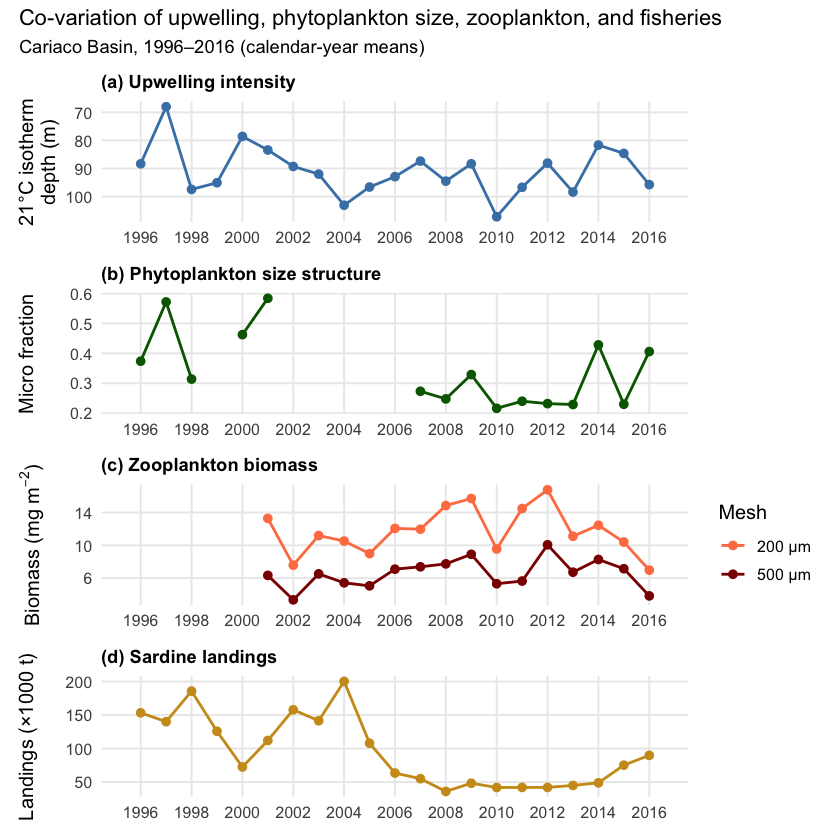

In [4]:
library(tidyverse)

# =============================================================================
# 0. LOAD DATA
# =============================================================================

dat <- readRDS("../../DATA/processed/CARIACO_EnvData_combined.rds")
fish <- readRDS("../../DATA/processed/fisheries.rds")

# Parse time_month into proper date components
dat <- dat %>%
  mutate(
    month = as.integer(sub("-.*", "", time_month)),
    year  = as.integer(sub(".*-", "", time_month))
  )

# =============================================================================
# 1. DERIVED METRICS (Todo 1.1)
# =============================================================================

dat <- dat %>%
  mutate(
    # Micro:pico ratio (guard against division by zero)
    micro_pico_ratio = ifelse(pico > 0, micro / pico, NA_real_),
    
    # Log ratio is often better behaved for plotting/stats
    log_micro_pico = ifelse(pico > 0 & micro > 0, log10(micro / pico), NA_real_),
    
    # Zoo large:small proxy (Todo 1.2)
    zoo_500_200_ratio = ifelse(BIOMASS_200 > 0, BIOMASS_500 / BIOMASS_200, NA_real_),
    
    # Total zooplankton biomass (sum of both mesh sizes)
    zoo_total = BIOMASS_200 + BIOMASS_500,
    
    # Season flag (upwelling = Nov-May, rainy = Jun-Oct)
    season = ifelse(month %in% c(1:5, 11, 12), "upwelling", "rainy")
  )

# =============================================================================
# 2. SEASONAL CHARACTERIZATION (Todo 1.1)
# =============================================================================

seasonal_summary <- dat %>%
  group_by(season) %>%
  summarise(
    n_micro      = sum(!is.na(micro)),
    micro_mean   = mean(micro, na.rm = TRUE),
    micro_sd     = sd(micro, na.rm = TRUE),
    pico_mean    = mean(pico, na.rm = TRUE),
    nano_mean    = mean(nano, na.rm = TRUE),
    ratio_mean   = mean(micro_pico_ratio, na.rm = TRUE),
    ratio_sd     = sd(micro_pico_ratio, na.rm = TRUE),
    chl_mean     = mean(Tot_Chl_a, na.rm = TRUE),
    iso21_mean   = mean(Isotherm_21, na.rm = TRUE),
    zoo200_mean  = mean(BIOMASS_200, na.rm = TRUE),
    zoo500_mean  = mean(BIOMASS_500, na.rm = TRUE),
    .groups = "drop"
  )

cat("\n=== Seasonal summary ===\n")
print(seasonal_summary)

# =============================================================================
# 3. CALENDAR-YEAR ANNUAL MEANS (Todo 1.1 / 1.2 / 1.4)
# =============================================================================

# Define which variables to aggregate annually
annual_vars <- c(
  # Bottom-up / physical
  "Isotherm_21", "SST", "MLD", "NO3_merged", "u10",
  # Size fractions
  "micro", "nano", "pico", "micro_pico_ratio", "log_micro_pico",
  "size_centroid", "Tot_Chl_a",
  # Zooplankton
  "BIOMASS_200", "BIOMASS_500", "zoo_500_200_ratio", "zoo_total",
  "copepod_frac_200", "calanoid_frac_200",
  # Climate indices (if already merged)
  "AMO", "MEIv2"
)

# Keep only columns that actually exist in dat
annual_vars <- intersect(annual_vars, names(dat))

annual_means <- dat %>%
  group_by(year) %>%
  summarise(
    across(all_of(annual_vars), 
           list(mean = ~mean(.x, na.rm = TRUE),
                n    = ~sum(!is.na(.x))),
           .names = "{.col}__{.fn}"),
    .groups = "drop"
  )

# Quick diagnostic: how many HPLC obs per year?
hplc_coverage <- annual_means %>%
  select(year, micro__n) %>%
  rename(n_hplc = micro__n)

cat("\n=== HPLC observations per year ===\n")
print(hplc_coverage, n = 30)

# Optional: set annual means to NA where n is below a threshold
min_n <- 2

mean_cols <- names(annual_means)[grepl("__mean$", names(annual_means))]

annual_clean <- annual_means
for (col in mean_cols) {
  n_col <- sub("__mean$", "__n", col)
  annual_clean[[col]] <- ifelse(annual_clean[[n_col]] >= min_n, 
                                annual_clean[[col]], 
                                NA_real_)
}

# =============================================================================
# 4. MERGE FISHERIES DATA (Todo 1.3)
# =============================================================================

annual_plot <- annual_clean %>%
  left_join(fish, by = "year")

# =============================================================================
# 5. MULTI-PANEL SYNTHESIS FIGURE (Todo 1.5)
# =============================================================================

# Restrict to CARIACO era
annual_plot <- annual_plot %>%
  filter(year >= 1996, year <= 2016)

# --- Build the figure ---
p_synthesis <- ggplot(annual_plot, aes(x = year)) +
  
  # Panel a: Upwelling proxy (Isotherm depth — note: deeper = weaker upwelling)
  # Reverse y-axis so shallower (stronger upwelling) is up
  geom_line(aes(y = Isotherm_21__mean), color = "steelblue", linewidth = 0.8,
            data = . %>% filter(!is.na(Isotherm_21__mean))) +
  geom_point(aes(y = Isotherm_21__mean), color = "steelblue", size = 2,
             data = . %>% filter(!is.na(Isotherm_21__mean))) +
  
  facet_wrap(~ "placeholder", scales = "free_y") +  # placeholder — replaced below
  theme_minimal()

# Better to build each panel separately for full control:

theme_panel <- theme_minimal(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    plot.title = element_text(size = 11, face = "bold"),
    axis.title.x = element_blank()
  )

xlims <- scale_x_continuous(breaks = seq(1996, 2016, 2), limits = c(1995.5, 2016.5))

# Panel a: Isotherm depth (reversed — shallow = strong upwelling at top)
pa <- ggplot(annual_plot, aes(year, Isotherm_21__mean)) +
  geom_line(color = "steelblue", linewidth = 0.8, na.rm = TRUE) +
  geom_point(color = "steelblue", size = 2, na.rm = TRUE) +
  scale_y_reverse() +
  xlims + theme_panel +
  labs(y = "21°C isotherm\ndepth (m)", title = "(a) Upwelling intensity")

# Panel b: Micro fraction (or micro:pico ratio)
pb <- ggplot(annual_plot, aes(year, micro__mean)) +
  geom_line(color = "darkgreen", linewidth = 0.8, na.rm = TRUE) +
  geom_point(color = "darkgreen", size = 2, na.rm = TRUE) +
  xlims + theme_panel +
  labs(y = "Micro fraction", title = "(b) Phytoplankton size structure")

# Panel c: Zooplankton biomass (both mesh sizes)
pc <- annual_plot %>%
  select(year, BIOMASS_200__mean, BIOMASS_500__mean) %>%
  pivot_longer(-year, names_to = "mesh", values_to = "biomass") %>%
  mutate(mesh = ifelse(grepl("200", mesh), "200 µm", "500 µm")) %>%
  ggplot(aes(year, biomass, color = mesh)) +
  geom_line(linewidth = 0.8, na.rm = TRUE) +
  geom_point(size = 2, na.rm = TRUE) +
  scale_color_manual(values = c("200 µm" = "coral", "500 µm" = "darkred")) +
  xlims + theme_panel +
  labs(y = expression("Biomass (mg m"^{-2}*")"), 
       title = "(c) Zooplankton biomass",
       color = "Mesh")

# Panel d: Sardine landings
pd <- ggplot(annual_plot, aes(year, sardinelandings / 1000)) +
  geom_line(color = "goldenrod3", linewidth = 0.8, na.rm = TRUE) +
  geom_point(color = "goldenrod3", size = 2, na.rm = TRUE) +
  xlims + theme_panel +
  labs(y = "Landings (×1000 t)", title = "(d) Sardine landings",
       x = "Year")

# Combine
library(patchwork)
fig_synthesis <- pa / pb / pc / pd +
  plot_annotation(
    title = "Co-variation of upwelling, phytoplankton size, zooplankton, and fisheries",
    subtitle = "Cariaco Basin, 1996–2016 (calendar-year means)"
  )

# Display
print(fig_synthesis)

# Save
#ggsave("figures/synthesis_figure_v1.pdf", fig_synthesis, 
#       width = 8, height = 10, dpi = 300)
#ggsave("figures/synthesis_figure_v1.png", fig_synthesis, 
 #      width = 8, height = 10, dpi = 300)

#cat("\nSynthesis figure saved to figures/\n")

# =============================================================================
# 6. SAVE ANNUAL DATASET FOR LATER USE
# =============================================================================

#saveRDS(annual_plot, "processed/CARIACO_annual_means.rds")
#write.csv(annual_plot, "processed/CARIACO_annual_means.csv", row.names = FALSE)

#cat("Annual means saved to processed/CARIACO_annual_means.rds\n")

In [9]:
mean(dat$euphotic_depth, na.rm=T)

[1] 44.91574